In [ ]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# ==========================================
# ⚙️ 1. CONFIGURATION (ตั้งค่าพื้นฐาน)
# ==========================================
np.random.seed(1616)  # ล็อค Seed ให้ข้อมูลเหมือนเดิมทุกครั้ง
random.seed(1616)
NUM_ROOMS = 150
START_DATE = datetime(2025, 1, 1)
DAYS = 90  # จำลอง 3 เดือน (Q1 2025)

print("🚀 Starting Data Generation for 'Azure Stay' Hotel...")

# ==========================================
# 📊 2. CREATE DIMENSION TABLES (ตารางมิติ)
# ==========================================

# --- 2.1 dim_channels ---
channels_data = [
    {'channel_id': 'CH_DIR', 'channel_name': 'Direct Website', 'channel_type': 'Direct', 'commission_rate': 0.00},
    {'channel_id': 'CH_EXP', 'channel_name': 'Expedia', 'channel_type': 'OTA', 'commission_rate': 0.18},
    {'channel_id': 'CH_BKG', 'channel_name': 'Booking.com', 'channel_type': 'OTA', 'commission_rate': 0.15},
    {'channel_id': 'CH_WLK', 'channel_name': 'Walk-in', 'channel_type': 'Walk-in', 'commission_rate': 0.00},
    {'channel_id': 'CH_COR', 'channel_name': 'Corporate Agent', 'channel_type': 'Corporate', 'commission_rate': 0.10}
]
df_dim_channels = pd.DataFrame(channels_data)

# --- 2.2 dim_rate_codes ---
rate_codes_data = [
    {'rate_code_id': 'RC_RACK', 'rate_name': 'Rack Rate', 'description': 'Standard Walk-in Rate', 'is_commissionable': False},
    {'rate_code_id': 'RC_PROMO', 'rate_name': 'Seasonal Promo', 'description': '10% Off Standard', 'is_commissionable': True},
    {'rate_code_id': 'RC_NONREF', 'rate_name': 'Non-Refundable', 'description': 'Prepaid, No Cancellation', 'is_commissionable': True},
    {'rate_code_id': 'RC_CORP', 'rate_name': 'Corporate Negotiated', 'description': 'Fixed Rate for Partners', 'is_commissionable': False}
]
df_dim_rate_codes = pd.DataFrame(rate_codes_data)

# --- 2.3 dim_calendar & dim_room_inventory ---
calendar_list = []
inventory_list = []
date_range = [START_DATE + timedelta(days=x) for x in range(DAYS)]

for d in date_range:
    is_weekend = d.weekday() >= 5
    is_holiday = (d.month == 1 and d.day == 1) or (d.month == 2 and d.day == 14)
    season = 'High Season' if d.month in [1, 2] else 'Shoulder Season'

    calendar_list.append({
        'date_key': d.strftime('%Y-%m-%d'),
        'day_name': d.strftime('%A'),
        'is_weekend': is_weekend,
        'is_holiday': is_holiday,
        'season': season
    })

    # Inventory Logic (มีห้องเสียบ้าง 0-4 ห้อง)
    ooo = int(np.random.choice([0, 1, 2, 3, 4], p=[0.70, 0.15, 0.08, 0.05, 0.02]))
    inventory_list.append({
        'date': d.strftime('%Y-%m-%d'),
        'total_capacity': NUM_ROOMS,
        'rooms_out_of_order': ooo,
        'rooms_available_for_sale': NUM_ROOMS - ooo
    })

df_dim_calendar = pd.DataFrame(calendar_list)
df_dim_inventory = pd.DataFrame(inventory_list)

# --- 2.4 dim_segments (เพิ่มให้ schema ดูสมบูรณ์ขึ้น) ---
segments_data = [
    {'segment_id': 'SEG_LEI', 'segment_name': 'Leisure'},
    {'segment_id': 'SEG_BUS', 'segment_name': 'Business'},
    {'segment_id': 'SEG_TRA', 'segment_name': 'Transient'},
    {'segment_id': 'SEG_GRP', 'segment_name': 'Group'}
]
df_dim_segments = pd.DataFrame(segments_data)

# ==========================================
# 🏨 3. CREATE FACT_BOOKINGS (ตารางธุรกรรมหลัก)
# ==========================================
bookings_list = []
res_id = 10001
guest_id_base = 5000

room_types = [
    {'id': 'RT_STD', 'name': 'Standard Queen', 'price': 2200},
    {'id': 'RT_DLX', 'name': 'Deluxe King', 'price': 3500},
    {'id': 'RT_SUT', 'name': 'Suite', 'price': 6000}
]

segment_map = {
    'Leisure': 'SEG_LEI',
    'Business': 'SEG_BUS',
    'Transient': 'SEG_TRA',
    'Group': 'SEG_GRP'
}

channel_commission_map = df_dim_channels.set_index('channel_id')['commission_rate'].to_dict()

for d in date_range:
    weekday_num = d.weekday()
    is_wknd = weekday_num >= 5
    is_friday_or_saturday = weekday_num in [4, 5]

    # ⚠️ BUSINESS LOGIC: สร้างปัญหา Revenue Stagnation
    # วันหยุดคนเต็ม แต่วันธรรมดาน้อย
    occ_rate = np.random.uniform(0.90, 0.98) if is_wknd else np.random.uniform(0.55, 0.70)
    daily_cap = NUM_ROOMS - df_dim_inventory.loc[
        df_dim_inventory['date'] == d.strftime('%Y-%m-%d'),
        'rooms_out_of_order'
    ].values[0]
    rooms_sold = int(daily_cap * occ_rate)

    for _ in range(rooms_sold):
        res_id += 1
        guest_id = f"GST-{guest_id_base + np.random.randint(1, 4000)}"

        # Bias Channel: OTA สูง เพื่อสะท้อนปัญหาค่าคอม
        ch = np.random.choice(
            df_dim_channels['channel_id'],
            p=[0.15, 0.40, 0.35, 0.05, 0.05]
        )

        # Room Type
        rt = np.random.choice(room_types, p=[0.65, 0.25, 0.10])

        # Segment
        seg_name = np.random.choice(
            ['Leisure', 'Business', 'Transient', 'Group'],
            p=[0.60, 0.20, 0.10, 0.10]
        )
        seg = segment_map[seg_name]

        # =========================
        # Lead Time & LOS
        # =========================
        lt = int(np.random.exponential(scale=18))

        # ⚠️ INVENTORY ISSUE:
        # ศุกร์/เสาร์ควรขายยาว แต่ระบบรับ short-stay เยอะ
        if is_friday_or_saturday:
            los = int(np.random.choice([1, 2, 3, 4], p=[0.60, 0.25, 0.10, 0.05]))
        else:
            los = int(np.random.choice([1, 2, 3, 4], p=[0.45, 0.35, 0.15, 0.05]))

        booking_date = d - timedelta(days=lt)
        check_out_date = d + timedelta(days=los)

        # =========================
        # Rate Code Logic
        # =========================
        # ให้ discount rate เกิดมากขึ้นในช่วง demand ต่ำ/จองใกล้วัน
        # และ weekend ยังมี promo/nonref เยอะเกินไป → pricing issue
        if is_wknd:
            rc = np.random.choice(
                df_dim_rate_codes['rate_code_id'],
                p=[0.15, 0.35, 0.35, 0.15]
            )
        else:
            rc = np.random.choice(
                df_dim_rate_codes['rate_code_id'],
                p=[0.08, 0.45, 0.37, 0.10]
            )

        # =========================
        # Pricing Logic
        # =========================
        base_price = rt['price']

        # ⚠️ PRICING ISSUE (Underpricing on high demand):
        # weekend ควรขึ้นเยอะกว่านี้ แต่ขึ้นน้อยเกินไป
        demand_multiplier = 1.05 if is_wknd else 1.00

        # holiday มี demand สูงขึ้น แต่ก็ยังขึ้นไม่มาก
        if (d.month == 1 and d.day == 1) or (d.month == 2 and d.day == 14):
            demand_multiplier *= 1.05

        discount = 1.0
        if rc == 'RC_PROMO':
            discount = 0.90
        elif rc == 'RC_NONREF':
            discount = 0.85
        elif rc == 'RC_CORP':
            discount = 0.88

        # OTA กดราคาลงอีก → ทำให้ gross revenue ต่ำลง
        if ch in ['CH_EXP', 'CH_BKG']:
            discount *= 0.95

        gross_daily_rate = base_price * demand_multiplier * discount
        total_rev = gross_daily_rate * los

        # =========================
        # Booking Status
        # =========================
        # Non-refundable มี cancel ต่ำกว่า
        if rc == 'RC_NONREF':
            status = np.random.choice(['Checked-Out', 'Cancelled', 'No-Show'], p=[0.95, 0.03, 0.02])
        else:
            status = np.random.choice(['Checked-Out', 'Cancelled', 'No-Show'], p=[0.88, 0.10, 0.02])

        # ถ้า Cancelled ส่วนใหญ่ไม่ได้รายได้
        if status == 'Cancelled' and np.random.rand() > 0.10:
            total_rev = 0.0

        adults = int(np.random.choice([1, 2, 3], p=[0.30, 0.60, 0.10]))
        children = int(np.random.choice([0, 1, 2], p=[0.70, 0.20, 0.10]))

        commission_rate = channel_commission_map[ch]
        commission_amount = round(total_rev * commission_rate, 2)
        net_room_revenue = round(total_rev - commission_amount, 2)

        bookings_list.append({
            'booking_id': f"RES-{res_id}",
            'guest_id': guest_id,
            'booking_date': booking_date.strftime('%Y-%m-%d'),
            'check_in_date': d.strftime('%Y-%m-%d'),
            'check_out_date': check_out_date.strftime('%Y-%m-%d'),
            'room_type_id': rt['id'],
            'rate_code_id': rc,
            'channel_id': ch,
            'segment_id': seg,
            'status': status,
            'total_room_revenue': round(total_rev, 2),
            'commission_amount': commission_amount,
            'net_room_revenue': net_room_revenue,
            'number_of_rooms': 1,
            'adults_count': adults,
            'children_count': children
        })

df_fact_bookings = pd.DataFrame(bookings_list)

# --- 🎯 Injecting Dirty Data (เพิ่มความสมจริงสำหรับ EDA) ---
# ทำยอดเงินติดลบ, วันที่หาย
dirty_idx = np.random.choice(df_fact_bookings.index, 10, replace=False)
df_fact_bookings.loc[dirty_idx[:5], 'total_room_revenue'] = -500.0
df_fact_bookings.loc[dirty_idx[:5], 'commission_amount'] = 0.0
df_fact_bookings.loc[dirty_idx[:5], 'net_room_revenue'] = -500.0
df_fact_bookings.loc[dirty_idx[5:], 'adults_count'] = None

# ==========================================
# 💾 4. EXPORT TO CSV
# ==========================================
df_fact_bookings.to_csv('fact_bookings.csv', index=False)
df_dim_inventory.to_csv('dim_room_inventory.csv', index=False)
df_dim_channels.to_csv('dim_channels.csv', index=False)
df_dim_rate_codes.to_csv('dim_rate_codes.csv', index=False)
df_dim_calendar.to_csv('dim_calendar.csv', index=False)
df_dim_segments.to_csv('dim_segments.csv', index=False)

print(f"✅ Generated 6 CSV files successfully!")
print(f"Total Transactions in fact_bookings: {len(df_fact_bookings)} rows.")

🚀 Starting Data Generation for 'Azure Stay' Hotel...
✅ Generated 6 CSV files successfully!
Total Transactions in fact_bookings: 9515 rows.


### 📊 Step 0: Data Overview & Profiling
ทำความเข้าใจโครงสร้างและลักษณะเบื้องต้นของข้อมูลทั้งหมดที่มี

In [ ]:
# ตรวจสอบขนาดของข้อมูล (Rows, Columns)
print(f"Fact Bookings Shape: {df_fact_bookings.shape}")

# ดูตัวอย่างข้อมูล 5 แถวแรก
print("\n--- Sample Data ---")
display(df_fact_bookings.head())

# ตรวจสอบความหลากหลายของข้อมูล (Unique Values)
unique_counts = df_fact_bookings.nunique()
print("\n--- Unique Values per Column ---")
display(unique_counts)

# ดูประเภทของห้องพักและช่องทางทั้งหมดที่มีใน Dimension Tables
print("\n--- Channels & Rate Codes Summary ---")
print(f"Available Channels: {df_dim_channels['channel_name'].unique()}")
print(f"Available Rate Codes: {df_dim_rate_codes['rate_name'].unique()}")

Fact Bookings Shape: (9515, 16)

--- Sample Data ---


,booking_id,guest_id,booking_date,check_in_date,check_out_date,room_type_id,rate_code_id,channel_id,segment_id,status,total_room_revenue,commission_amount,net_room_revenue,number_of_rooms,adults_count,children_count
0,RES-10002,GST-7513,2024-12-25,2025-01-01,2025-01-02,RT_STD,RC_CORP,CH_EXP,SEG_LEI,Checked-Out,1931.16,347.61,1583.55,1,1.0,0
1,RES-10003,GST-7318,2024-12-04,2025-01-01,2025-01-04,RT_STD,RC_PROMO,CH_BKG,SEG_LEI,Checked-Out,5925.15,888.77,5036.38,1,2.0,0
2,RES-10004,GST-8515,2024-12-09,2025-01-01,2025-01-02,RT_STD,RC_PROMO,CH_WLK,SEG_LEI,Checked-Out,2079.00,0.00,2079.00,1,1.0,1
3,RES-10005,GST-6459,2024-12-26,2025-01-01,2025-01-02,RT_STD,RC_NONREF,CH_EXP,SEG_LEI,Checked-Out,1865.33,335.76,1529.57,1,2.0,1
4,RES-10006,GST-7301,2024-12-26,2025-01-01,2025-01-02,RT_STD,RC_CORP,CH_BKG,SEG_LEI,Checked-Out,1931.16,289.67,1641.49,1,2.0,0



--- Unique Values per Column ---


,0
booking_id,9515
guest_id,3624
booking_date,185
check_in_date,90
check_out_date,93
room_type_id,3
rate_code_id,4
channel_id,5
segment_id,4
status,3



--- Channels & Rate Codes Summary ---
Available Channels: ['Direct Website' 'Expedia' 'Booking.com' 'Walk-in' 'Corporate Agent']
Available Rate Codes: ['Rack Rate' 'Seasonal Promo' 'Non-Refundable' 'Corporate Negotiated']


### 🧹 Step 1: Data Profiling & Cleaning
เราจะเริ่มจากการตรวจสอบภาพรวมของ `df_fact_bookings` เพื่อหาจุดที่ต้องแก้ไข

In [ ]:
# 1. ตรวจสอบ Missing Values และ Data Types
print("--- Data Info ---")
display(df_fact_bookings.info())

print("\n--- Missing Values Count ---")
display(df_fact_bookings.isnull().sum())

# 2. ตรวจสอบความผิดปกติของตัวเลข (เช่น ติดลบ)
print("\n--- Descriptive Statistics (Summary) ---")
display(df_fact_bookings[['total_room_revenue', 'adults_count', 'children_count']].describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   booking_id          9515 non-null   object 
 1   guest_id            9515 non-null   object 
 2   booking_date        9515 non-null   object 
 3   check_in_date       9515 non-null   object 
 4   check_out_date      9515 non-null   object 
 5   room_type_id        9515 non-null   object 
 6   rate_code_id        9515 non-null   object 
 7   channel_id          9515 non-null   object 
 8   segment_id          9515 non-null   object 
 9   status              9515 non-null   object 
 10  total_room_revenue  9515 non-null   float64
 11  commission_amount   9515 non-null   float64
 12  net_room_revenue    9515 non-null   float64
 13  number_of_rooms     9515 non-null   int64  
 14  adults_count        9510 non-null   float64
 15  children_count      9515 non-null   i

None


--- Missing Values Count ---


,0
booking_id,0
guest_id,0
booking_date,0
check_in_date,0
check_out_date,0
room_type_id,0
rate_code_id,0
channel_id,0
segment_id,0
status,0



--- Descriptive Statistics (Summary) ---


,total_room_revenue,adults_count,children_count
count,9515.000000,9510.000000,9515.000000
mean,4102.550704,1.790326,0.389490
std,3116.322232,0.598655,0.660338
min,-500.000000,1.000000,0.000000
25%,1931.160000,1.000000,0.000000
50%,3553.000000,2.000000,0.000000
75%,5610.000000,2.000000,1.000000
max,25200.000000,3.000000,2.000000


### 🛠 แก้ไขข้อมูล (Data Correction)
เราจะทำการ Fix ข้อมูลที่ผิดปกติให้กลับมาใช้งานได้

In [ ]:
# 1. แก้ไขค่า Revenue ที่ติดลบ (ในกรณีนี้เราจะปัดให้เป็น 0 หรือค่าเฉลี่ย แต่เพื่อความง่ายเราจะลบ row ที่ผิดปกติทิ้ง)
df_cleaned = df_fact_bookings[df_fact_bookings['total_room_revenue'] >= 0].copy()

# 2. จัดการ Missing Values ใน adults_count (แทนที่ด้วยค่าฐานนิยม - Mode คือ 2 คน)
adults_mode = df_cleaned['adults_count'].mode()[0]
df_cleaned['adults_count'] = df_cleaned['adults_count'].fillna(adults_mode)

# 3. แปลงคอลัมน์วันที่จาก String เป็น Datetime objects
date_cols = ['booking_date', 'check_in_date', 'check_out_date']
for col in date_cols:
    df_cleaned[col] = pd.to_datetime(df_cleaned[col])

# 4. ตรวจสอบความซ้ำซ้อน (Duplicates)
duplicates_count = df_cleaned.duplicated(subset=['booking_id']).sum()
print(f"Found {duplicates_count} duplicated booking IDs.")

print("✅ Data Cleaning Completed!")
display(df_cleaned.head())

Found 0 duplicated booking IDs.
✅ Data Cleaning Completed!


,booking_id,guest_id,booking_date,check_in_date,check_out_date,room_type_id,rate_code_id,channel_id,segment_id,status,total_room_revenue,commission_amount,net_room_revenue,number_of_rooms,adults_count,children_count
0,RES-10002,GST-7513,2024-12-25,2025-01-01,2025-01-02,RT_STD,RC_CORP,CH_EXP,SEG_LEI,Checked-Out,1931.16,347.61,1583.55,1,1.0,0
1,RES-10003,GST-7318,2024-12-04,2025-01-01,2025-01-04,RT_STD,RC_PROMO,CH_BKG,SEG_LEI,Checked-Out,5925.15,888.77,5036.38,1,2.0,0
2,RES-10004,GST-8515,2024-12-09,2025-01-01,2025-01-02,RT_STD,RC_PROMO,CH_WLK,SEG_LEI,Checked-Out,2079.00,0.00,2079.00,1,1.0,1
3,RES-10005,GST-6459,2024-12-26,2025-01-01,2025-01-02,RT_STD,RC_NONREF,CH_EXP,SEG_LEI,Checked-Out,1865.33,335.76,1529.57,1,2.0,1
4,RES-10006,GST-7301,2024-12-26,2025-01-01,2025-01-02,RT_STD,RC_CORP,CH_BKG,SEG_LEI,Checked-Out,1931.16,289.67,1641.49,1,2.0,0


### 🔄 Step 1.1: Data Transformation (Feature Engineering)
สร้างคอลัมน์ใหม่ที่จำเป็นสำหรับการวิเคราะห์พฤติกรรมลูกค้าและรายได้

In [ ]:
# 1. คำนวณ Lead Time (ระยะเวลาจองล่วงหน้า)
df_cleaned['lead_time'] = (df_cleaned['check_in_date'] - df_cleaned['booking_date']).dt.days

# 2. คำนวณ Length of Stay (จำนวนคืนที่พัก)
df_cleaned['los'] = (df_cleaned['check_out_date'] - df_cleaned['check_in_date']).dt.days

# 3. สกัดวันในสัปดาห์ที่ Check-in (0=Monday, 6=Sunday)
df_cleaned['arrival_day_of_week'] = df_cleaned['check_in_date'].dt.dayofweek
df_cleaned['arrival_day_name'] = df_cleaned['check_in_date'].dt.day_name()

# 4. ระบุว่าเป็นวันหยุดสุดสัปดาห์หรือไม่ (ศุกร์-เสาร์ สำหรับโรงแรมมักเป็น Weekend peak)
df_cleaned['is_weekend_stay'] = df_cleaned['arrival_day_of_week'].isin([4, 5])

# 5. คำนวณรายได้สุทธิต่อคืน (Net Rev per Night)
df_cleaned['net_rev_per_night'] = df_cleaned['net_room_revenue'] / df_cleaned['los']
# จัดการกรณี LOS เป็น 0 (ถ้ามี) เพื่อไม่ให้เกิด Error
df_cleaned['net_rev_per_night'] = df_cleaned['net_rev_per_night'].replace([np.inf, -np.inf], 0)

print("✅ Transformation Completed!")
display(df_cleaned[['booking_id', 'lead_time', 'los', 'arrival_day_name', 'net_rev_per_night']].head())

✅ Transformation Completed!


,booking_id,lead_time,los,arrival_day_name,net_rev_per_night
0,RES-10002,7,1,Wednesday,1583.550000
1,RES-10003,28,3,Wednesday,1678.793333
2,RES-10004,23,1,Wednesday,2079.000000
3,RES-10005,6,1,Wednesday,1529.570000
4,RES-10006,6,1,Wednesday,1641.490000


### ✅ Step 1.2: Post-Transformation Validation
ตรวจสอบความถูกต้องของข้อมูลหลังจากสร้าง Features ใหม่

In [ ]:
# 1. เช็คว่ามีค่า Lead Time ติดลบไหม (ควรเป็น >= 0)
invalid_lt = df_cleaned[df_cleaned['lead_time'] < 0].shape[0]

# 2. เช็ค Missing Values ในคอลัมน์ใหม่
new_cols_null = df_cleaned[['lead_time', 'los', 'net_rev_per_night']].isnull().sum()

# 3. ดูสถิติเบื้องต้นของคอลัมน์ที่ Transform มา
print(f"--- Validation Summary ---")
print(f"Invalid Lead Times (< 0): {invalid_lt}")
print("\n--- Missing Values in New Columns ---")
print(new_cols_null)

print("\n--- Stats for New Features ---")
display(df_cleaned[['lead_time', 'los', 'net_rev_per_night']].describe())

# 4. เช็คความสมบูรณ์ของวันในสัปดาห์
print("\n--- Arrival Day Distribution ---")
print(df_cleaned['arrival_day_name'].value_counts())

--- Validation Summary ---
Invalid Lead Times (< 0): 0

--- Missing Values in New Columns ---
lead_time            0
los                  0
net_rev_per_night    0
dtype: int64

--- Stats for New Features ---


,lead_time,los,net_rev_per_night
count,9510.000000,9510.000000,9510.000000
mean,17.585384,1.733649,2071.980502
std,18.192212,0.865696,1077.961257
min,0.000000,1.000000,0.000000
25%,4.000000,1.000000,1542.420000
50%,12.000000,2.000000,1771.825000
75%,25.000000,2.000000,2487.100000
max,173.000000,4.000000,6300.000000



--- Arrival Day Distribution ---
arrival_day_name
Sunday       1832
Saturday     1820
Thursday     1191
Wednesday    1188
Friday       1186
Monday       1178
Tuesday      1115
Name: count, dtype: int64


### 💎 Step 1.3: Data Enriching
รวมข้อมูลจาก Dimension Tables เพื่อให้ได้ชื่อเรียกที่เข้าใจง่ายสำหรับการทำ Visualization

In [ ]:
# 1. Merge กับตาราง Channels เพื่อเอาชื่อช่องทาง
df_cleaned = df_cleaned.merge(df_dim_channels[['channel_id', 'channel_name']], on='channel_id', how='left')

# 2. Merge กับตาราง Segments เพื่อเอาชื่อกลุ่มลูกค้า
df_cleaned = df_cleaned.merge(df_dim_segments[['segment_id', 'segment_name']], on='segment_id', how='left')

# 3. Merge กับตาราง Room Types (ถ้าต้องการชื่อเต็ม)
room_types_df = pd.DataFrame([
    {'room_type_id': 'RT_STD', 'room_type_name': 'Standard Queen'},
    {'room_type_id': 'RT_DLX', 'room_type_name': 'Deluxe King'},
    {'room_type_id': 'RT_SUT', 'room_type_name': 'Suite'}
])
df_cleaned = df_cleaned.merge(room_types_df, on='room_type_id', how='left')

print("✅ Data Enrichment Completed!")
display(df_cleaned[['booking_id', 'channel_name', 'segment_name', 'room_type_name']].head())

✅ Data Enrichment Completed!


,booking_id,channel_name,segment_name,room_type_name
0,RES-10002,Expedia,Leisure,Standard Queen
1,RES-10003,Booking.com,Leisure,Standard Queen
2,RES-10004,Walk-in,Leisure,Standard Queen
3,RES-10005,Expedia,Leisure,Standard Queen
4,RES-10006,Booking.com,Leisure,Standard Queen


### 📈 Step 2: Exploratory Data Analysis (EDA)
เราจะคำนวณ KPIs สำคัญเพื่อดูสุขภาพทางการเงินของโรงแรม

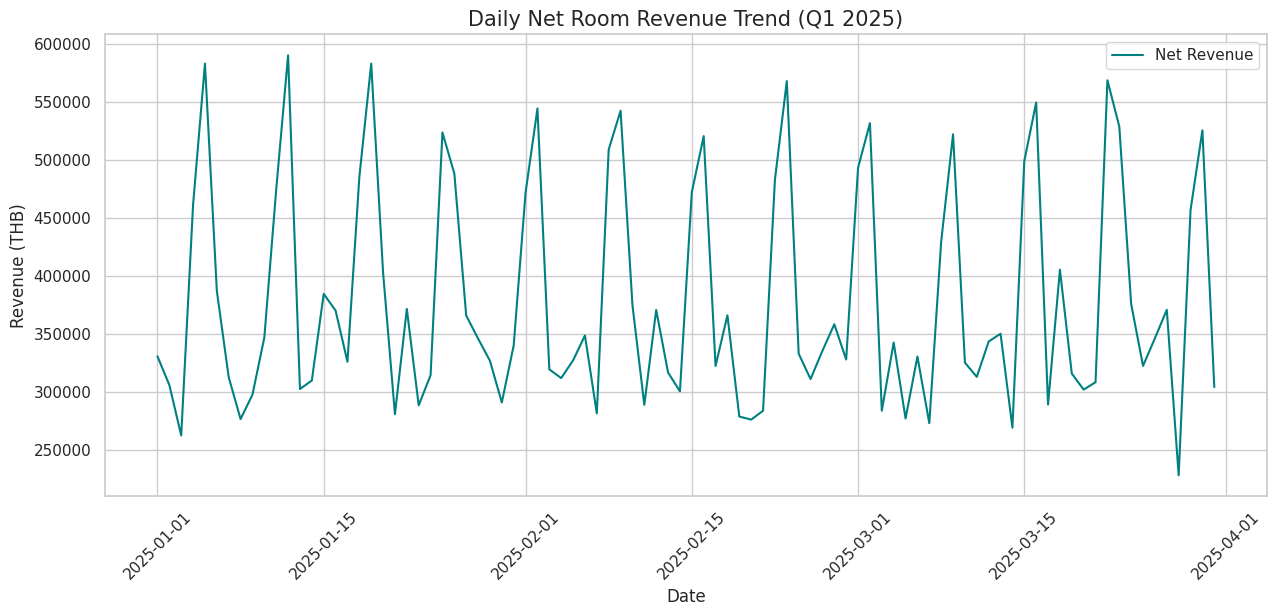

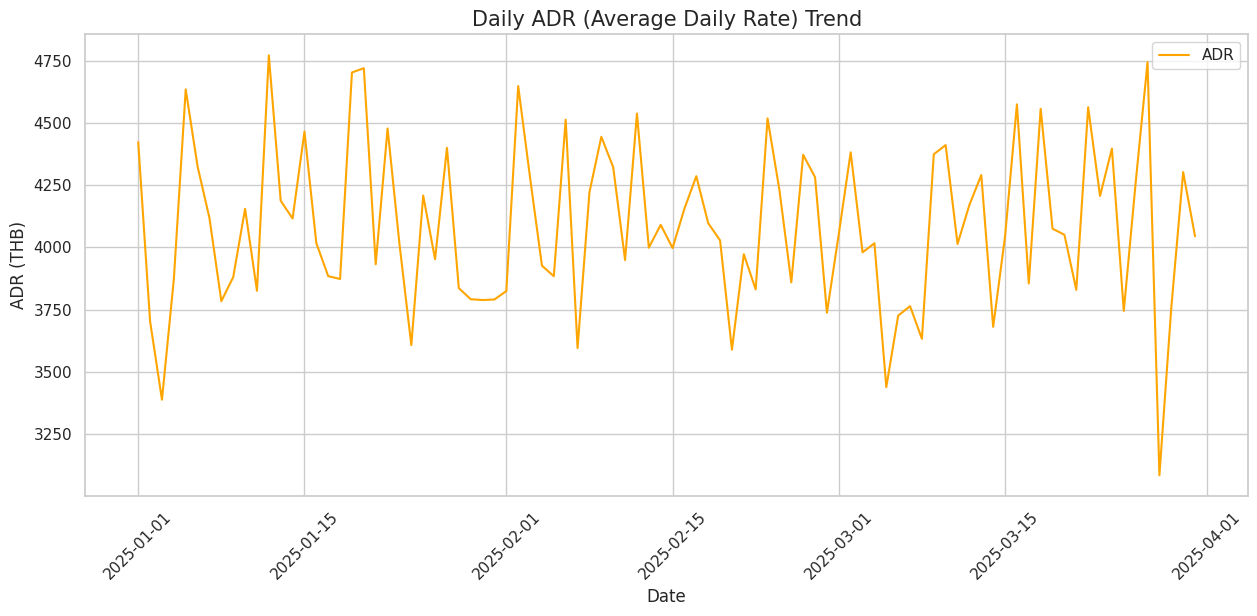

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# 1. คำนวณรายได้รายวัน
daily_revenue = df_cleaned.groupby('check_in_date')['net_room_revenue'].sum().reset_index()

# 2. คำนวณ ADR (Average Daily Rate) รายวัน
# ADR = Total Room Revenue / Number of Rooms Sold
daily_stats = df_cleaned.groupby('check_in_date').agg(
    total_rev=('total_room_revenue', 'sum'),
    rooms_sold=('number_of_rooms', 'sum')
).reset_index()
daily_stats['adr'] = daily_stats['total_rev'] / daily_stats['rooms_sold']

# 3. Visualization: Revenue Trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_revenue, x='check_in_date', y='net_room_revenue', color='teal', label='Net Revenue')
plt.title('Daily Net Room Revenue Trend (Q1 2025)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Revenue (THB)')
plt.xticks(rotation=45)
plt.show()

# 4. Visualization: ADR Trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_stats, x='check_in_date', y='adr', color='orange', label='ADR')
plt.title('Daily ADR (Average Daily Rate) Trend', fontsize=15)
plt.xlabel('Date')
plt.ylabel('ADR (THB)')
plt.xticks(rotation=45)
plt.show()

### 🔌 Step 3: Channel Performance & Commission Analysis
วิเคราะห์ว่าช่องทางการจองแต่ละประเภทสร้างรายได้สุทธิ (Net Revenue) ให้เราเท่าไหร่

/tmp/ipykernel_38018/3098201951.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_analysis, x='channel_id', y='net_revenue', ax=ax1, palette='viridis')


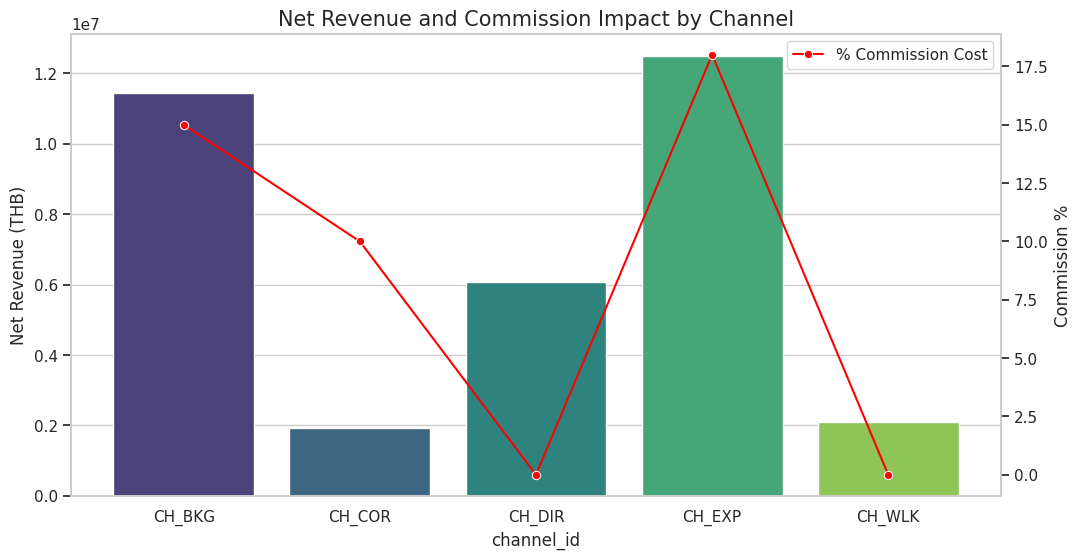

,channel_id,total_bookings,gross_revenue,total_commission,net_revenue,commission_pct
3,CH_EXP,3812,15244629.09,2744032.92,12500597.09,17.999998
0,CH_BKG,3302,13477512.31,2021626.51,11455885.68,14.999998
2,CH_DIR,1421,6063971.75,0.00,6063971.75,0.000000
4,CH_WLK,503,2109140.35,0.00,2109140.35,0.000000
1,CH_COR,472,2143016.45,214301.68,1928714.77,10.000002


In [ ]:
# 1. สรุปรายได้และค่าคอมมิชชั่นแยกตาม Channel
channel_analysis = df_cleaned.groupby('channel_id').agg(
    total_bookings=('booking_id', 'count'),
    gross_revenue=('total_room_revenue', 'sum'),
    total_commission=('commission_amount', 'sum'),
    net_revenue=('net_room_revenue', 'sum')
).reset_index()

# คำนวณ % Commission Cost ของแต่ละ Channel
channel_analysis['commission_pct'] = (channel_analysis['total_commission'] / channel_analysis['gross_revenue']) * 100

# 2. Visualization: Net Revenue vs Commission by Channel
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=channel_analysis, x='channel_id', y='net_revenue', ax=ax1, palette='viridis')
ax1.set_title('Net Revenue and Commission Impact by Channel', fontsize=15)
ax1.set_ylabel('Net Revenue (THB)')

# เพิ่มเส้นแสดง % Commission
ax2 = ax1.twinx()
sns.lineplot(data=channel_analysis, x='channel_id', y='commission_pct', ax=ax2, color='red', marker='o', label='% Commission Cost')
ax2.set_ylabel('Commission %')
ax2.grid(False)

plt.show()

display(channel_analysis.sort_values(by='net_revenue', ascending=False))

### 👥 Step 4: Segment & Behavior Analysis
วิเคราะห์พฤติกรรมลูกค้าแยกตาม Segment เพื่อหาโอกาสในการทำโปรโมชั่น

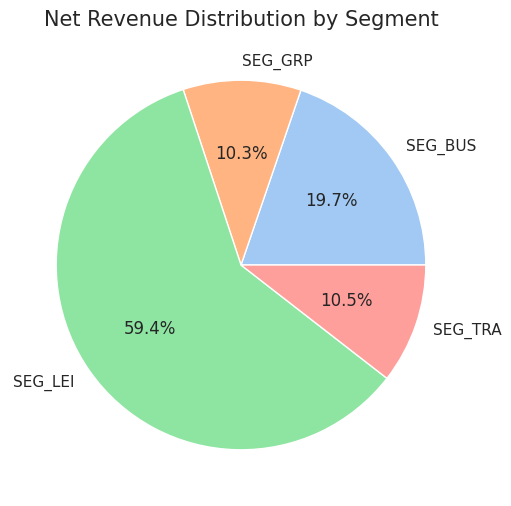

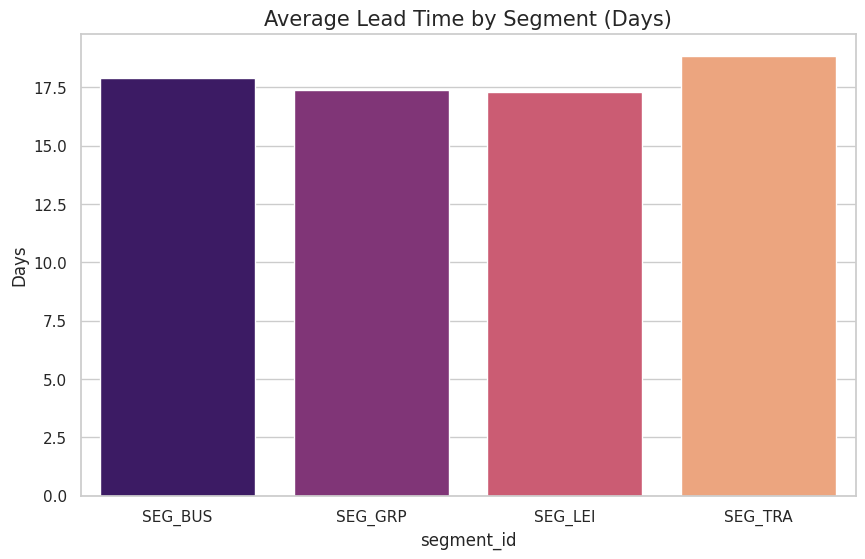

,segment_id,total_bookings,avg_lead_time,total_net_rev
0,SEG_BUS,1882,17.909139,6725194.63
1,SEG_GRP,968,17.368802,3515222.97
2,SEG_LEI,5701,17.302403,20239228.70
3,SEG_TRA,959,18.850886,3578663.34


In [ ]:
# 1. วิเคราะห์รายได้แยกตาม Segment
segment_analysis = df_cleaned.groupby('segment_id').agg(
    total_bookings=('booking_id', 'count'),
    avg_lead_time=('booking_date', lambda x: (df_cleaned.loc[x.index, 'check_in_date'] - x).dt.days.mean()),
    total_net_rev=('net_room_revenue', 'sum')
).reset_index()

# 2. Visualization: Net Revenue by Segment
plt.figure(figsize=(10, 6))
plt.pie(segment_analysis['total_net_rev'], labels=segment_analysis['segment_id'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Net Revenue Distribution by Segment', fontsize=15)
plt.show()

# 3. Visualization: Lead Time by Segment
plt.figure(figsize=(10, 6))
sns.barplot(data=segment_analysis, x='segment_id', y='avg_lead_time', hue='segment_id', palette='magma', legend=False)
plt.title('Average Lead Time by Segment (Days)', fontsize=15)
plt.ylabel('Days')
plt.show()

display(segment_analysis)

### 🏁 Step 5: Summary & Strategic Recommendations

จากการวิเคราะห์ข้อมูลธุรกรรมของ **Azure Stay** ในช่วง Q1 2025 พบประเด็นสำคัญที่ส่งผลต่อรายได้และความยั่งยืนของธุรกิจ ดังนี้:

#### 📌 Key Insights (ข้อค้นพบสำคัญ):
1. **High OTA Dependency & Commission Leakage:**
   - รายได้ส่วนใหญ่มาจาก **Expedia (CH_EXP)** และ **Booking.com (CH_BKG)** ซึ่งมีสัดส่วนรวมกันกว่า 70% ของยอดจอง
   - ส่งผลให้โรงแรมต้องจ่ายค่าคอมมิชชั่นสูงถึง 15-18% ซึ่งกัดกิน Net Revenue อย่างมีนัยสำคัญ เมื่อเทียบกับการจองตรง (Direct) ที่ไม่มีต้นทุนส่วนนี้
2. **Weekend vs. Weekday Imbalance (Revenue Stagnation):**
   - อัตราการเข้าพัก (Occupancy) ในวันหยุด (ศุกร์-เสาร์) สูงถึง 90-98% แต่ในวันธรรมดากลับตกลงมาอยู่ที่ 55-70%
   - กราฟ Daily Revenue แสดงให้เห็นถึง 'ฟันปลา' ที่ชัดเจน ซึ่งหมายถึงเรายังไม่สามารถดึง Demand ในวันธรรมดาได้ดีพอ
3. **Static Pricing in High Demand:**
   - แม้ในช่วงวันหยุดหรือเทศกาล (เช่น New Year, Valentine's) ค่า ADR (Average Daily Rate) ปรับตัวสูงขึ้นเพียงเล็กน้อย
   - แสดงว่าระบบ Pricing ยังไม่ได้ใช้กลยุทธ์ **Dynamic Pricing** อย่างเต็มที่เพื่อรีดรายได้ (Yield) จากช่วงที่มี Demand ล้นมือ
4. **Customer Behavior:**
   - กลุ่ม **Leisure** มี Lead Time เฉลี่ยอยู่ที่ประมาณ 17-18 วัน และมักจองผ่าน OTA ในขณะที่กลุ่ม Corporate มี Net Revenue ต่อคืนที่ค่อนข้างคงที่แต่จำนวนยังน้อย

#### 🚀 Strategic Recommendations (แนวทางเพิ่มรายได้):
1. **Shift to Direct Bookings (Direct-First Strategy):**
   - ทำแคมเปญ **"Book Direct & Save"** โดยมอบสิทธิประโยชน์ที่ OTA ให้ไม่ได้ เช่น Free Early Check-in, Late Check-out หรือ Voucher อาหารและเครื่องดื่ม
   - ใช้ Guest ID เพื่อทำ CRM/Loyalty Program ดึงลูกค้าเก่ากลับมาจองตรงในครั้งถัดไป
2. **Aggressive Dynamic Pricing:**
   - ในช่วงวันหยุดที่ Occupancy คาดการณ์ว่าจะเกิน 80% ควรปรับเพิ่มราคา Rack Rate ขึ้นอีกอย่างน้อย 20-30%
   - จำกัดการใช้ Promo Code หรือ Non-refundable rate ที่ให้ส่วนลดสูงเกินไปในช่วง Peak Period
3. **Mid-week Demand Generation:**
   - ออกแพ็กเกจ **"Stay Longer, Pay Less"** สำหรับคนที่พัก 3 คืนขึ้นไป (ครอบคลุมวันธรรมดา)
   - ร่วมมือกับบริษัทในพื้นที่เพื่อทำ **Corporate Contract** ดึงกลุ่ม Business Traveler มาพักในช่วงวันจันทร์-พฤหัสบดี
4. **Channel Mix Optimization:**
   - พิจารณาปิดการขาย (Close out) บนช่องทาง OTA ที่ค่าคอมมิชชั่นสูงในช่วงที่ห้องใกล้เต็ม เพื่อเหลือห้องไว้ขายผ่านหน้าเว็บตัวเองหรือ Walk-in ที่ได้กำไรเต็มเม็ดเต็มหน่วยมากกว่า

### 📝 สรุปขั้นตอนการเตรียมข้อมูล (Data Preparation Summary)

จากข้อมูลดิบ (Raw Data) ที่ถูกสร้างขึ้น เราได้ดำเนินการดังนี้เพื่อเตรียมข้อมูลให้พร้อมสำหรับการวิเคราะห์:

1.  **Data Profiling (การสำรวจข้อมูล):**
    *   ตรวจสอบขนาดข้อมูล (Shape) และค่าที่เป็นเอกลักษณ์ (Unique Values)
    *   ระบุปัญหาในข้อมูล เช่น ค่าที่หายไป (Missing Values) และข้อมูลที่ผิดปกติ (Anomalies)

2.  **Data Cleaning (การล้างข้อมูล):**
    *   **จัดการค่าที่หายไป:** เติมค่าว่างใน `adults_count` ด้วยค่า Mode (2 คน)
    *   **จัดการข้อมูลผิดปกติ:** ลบรายการที่มีรายได้ (`total_room_revenue`) ติดลบออก
    *   **แก้ไข Data Types:** แปลงคอลัมน์วันที่จาก String เป็น `datetime` objects

3.  **Feature Engineering (การสร้างตัวแปรใหม่):**
    *   `lead_time`: ระยะเวลาจองล่วงหน้า (วัน)
    *   `los`: จำนวนคืนที่เข้าพัก (Length of Stay)
    *   `arrival_day_name`: ชื่อวันในสัปดาห์ที่ Check-in
    *   `is_weekend_stay`: แยกแยะช่วงวันหยุดสุดสัปดาห์ (ศุกร์-เสาร์)
    *   `net_rev_per_night`: รายได้สุทธิต่อคืน

4.  **Data Enrichment (การเสริมข้อมูล):**
    *   ทำการ Merge ข้อมูลจาก Dimension Tables เพื่อนำชื่อเต็มของ Channels, Segments และ Room Types มาใช้งานแทน ID เพื่อความเข้าใจที่ง่ายขึ้นในการทำ Visualization